# Trabajo Práctico II - Visión por Computadora I

Alumnos:
- Maximiliano Christener
- Ronald Uthurralt
- Luis David Díaz Charris
- Juan Pablo Skobalski

## Objetivo

Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral.

Se implementa la métrica FM (Frequency Domain Image Blur Measure) propuesta en el paper
"Image Sharpness Measure for Blurred Images in Frequency Domain" (Kanjar De, V. Masilamani, 2013).

**Algoritmo:**
1. Calcular la FFT de la imagen
2. Centrar el espectro de frecuencias
3. Obtener el valor absoluto del espectro centrado (AF)
4. Calcular M = max(AF)
5. Definir threshold = M / 1000
6. Contar T_H = cantidad de píxeles con valor > threshold
7. FM = T_H / (ancho × alto)

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [27]:
def compute_fm(image_gray):
    # FFT y centrado
    f = np.fft.fft2(image_gray.astype(np.float64))
    fc = np.fft.fftshift(f)

    af = np.abs(fc)

    m = np.max(af)

    thres = m / 1000
    
    # Contamos píxeles sobre threshold
    t_h = np.sum(af > thres)

    rows, cols = image_gray.shape
    fm = t_h / (rows * cols)
    
    return fm

In [28]:
def detect_max_focus(fm_values):
    fm_array = np.array(fm_values)
    max_idx = np.argmax(fm_array)
    return max_idx, fm_array[max_idx]

## Carga del video

In [29]:
VIDEO_PATH = 'material/focus_video.mov'

cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f'Total frames: {total_frames}')
print(f'FPS: {fps}')
print(f'Resolución: {width}x{height}')

# Leemos en escala de grises
frames_gray = []
frames_color = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames_color.append(frame)
    frames_gray.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
cap.release()

print(f'Frames leídos: {len(frames_gray)}')

Total frames: 171
FPS: 29.97002997002997
Resolución: 640x360
Frames leídos: 171


## Experimento 1: Medición sobre todo el frame

In [30]:
fm_full = [compute_fm(frame) for frame in frames_gray]

max_frame_full, max_fm_full = detect_max_focus(fm_full)
print(f'Frame de máximo enfoque: {max_frame_full}')
print(f'Valor FM máximo: {max_fm_full:.4f}')

Frame de máximo enfoque: 109
Valor FM máximo: 0.0278


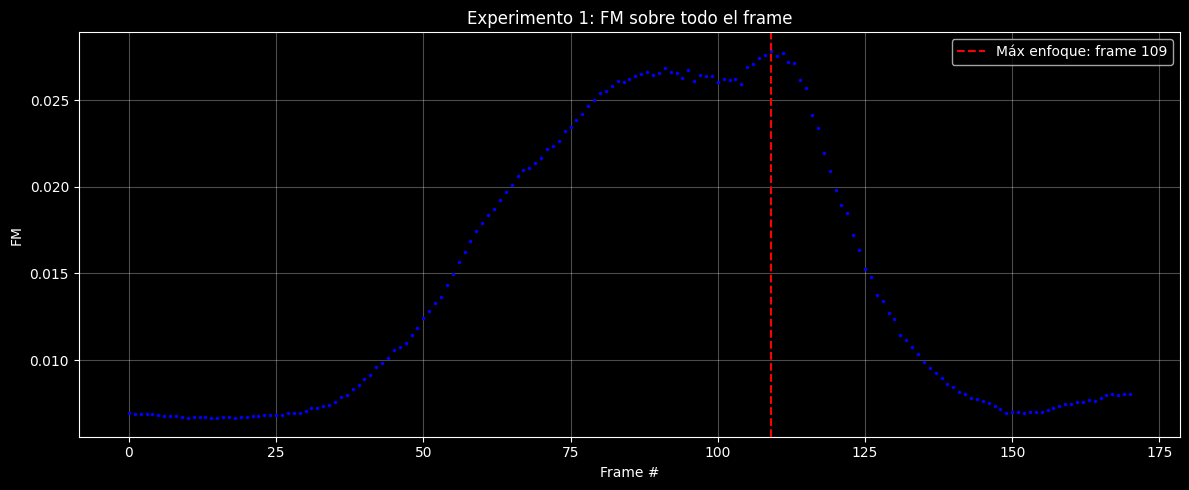

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fm_full, 'b.', markersize=3)
ax.axvline(x=max_frame_full, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_full}')
ax.set_xlabel('Frame #')
ax.set_ylabel('FM')
ax.set_title('Experimento 1: FM sobre todo el frame')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

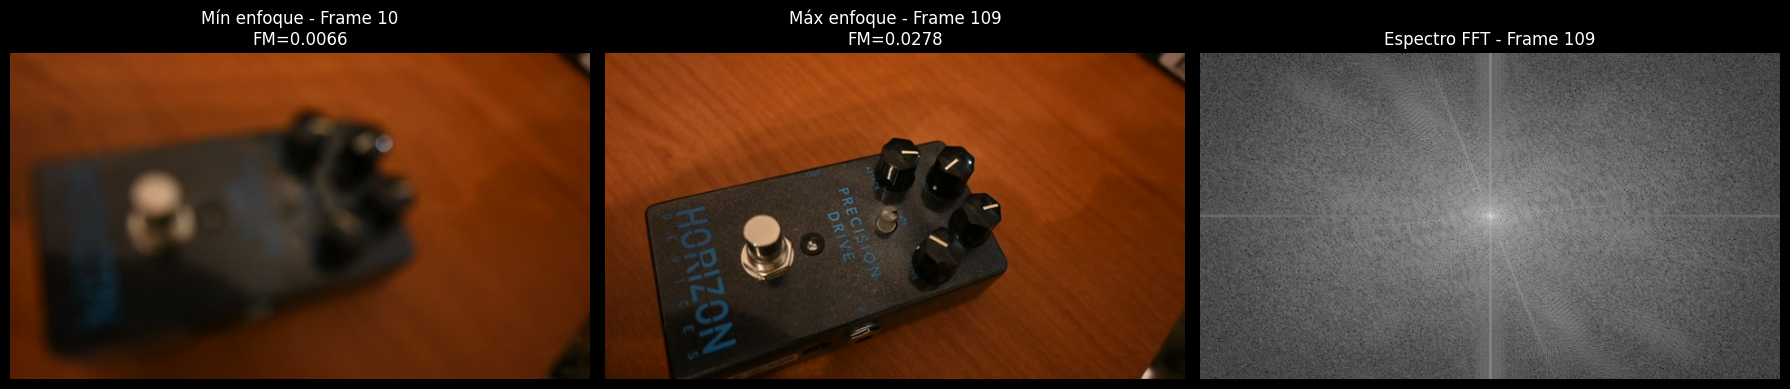

In [32]:
# Visualizar el frame de máximo enfoque
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Frame más borroso (mínimo FM)
min_frame = np.argmin(fm_full)
axes[0].imshow(cv2.cvtColor(frames_color[min_frame], cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Mín enfoque - Frame {min_frame}\nFM={fm_full[min_frame]:.4f}')
axes[0].axis('off')

# Frame de máximo enfoque
axes[1].imshow(cv2.cvtColor(frames_color[max_frame_full], cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Máx enfoque - Frame {max_frame_full}\nFM={max_fm_full:.4f}')
axes[1].axis('off')

# Espectro de frecuencia del frame de máximo enfoque
f = np.fft.fft2(frames_gray[max_frame_full].astype(np.float64))
fc = np.fft.fftshift(f)
magnitude = 20 * np.log(np.abs(fc) + 1)
axes[2].imshow(magnitude, cmap='gray')
axes[2].set_title(f'Espectro FFT - Frame {max_frame_full}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Experimento 2: Medición sobre ROI central (5% y 10% del área total)

In [33]:
def extract_center_roi(image, area_ratio):
    """Extrae una ROI centrada con un porcentaje del área total."""
    h, w = image.shape[:2]
    scale = np.sqrt(area_ratio)
    roi_w = int(w * scale)
    roi_h = int(h * scale)
    x_start = (w - roi_w) // 2
    y_start = (h - roi_h) // 2
    return image[y_start:y_start+roi_h, x_start:x_start+roi_w]

In [34]:
fm_roi_5 = [compute_fm(extract_center_roi(frame, 0.05)) for frame in frames_gray]
fm_roi_10 = [compute_fm(extract_center_roi(frame, 0.10)) for frame in frames_gray]

max_frame_5, max_fm_5 = detect_max_focus(fm_roi_5)
max_frame_10, max_fm_10 = detect_max_focus(fm_roi_10)

print(f'ROI 5%  - Frame máx enfoque: {max_frame_5}, FM={max_fm_5:.4f}')
print(f'ROI 10% - Frame máx enfoque: {max_frame_10}, FM={max_fm_10:.4f}')

ROI 5%  - Frame máx enfoque: 111, FM=0.4596
ROI 10% - Frame máx enfoque: 111, FM=0.3531


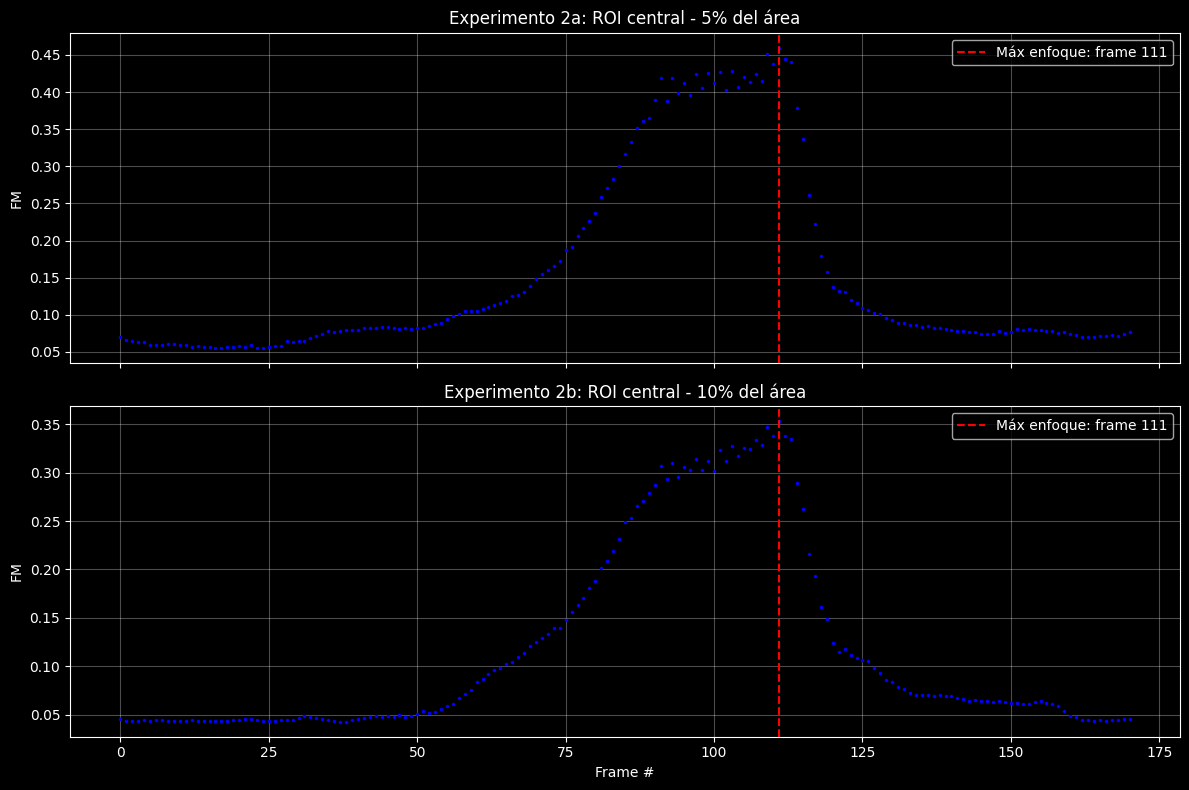

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(fm_roi_5, 'b.', markersize=3)
axes[0].axvline(x=max_frame_5, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_5}')
axes[0].set_ylabel('FM')
axes[0].set_title('Experimento 2a: ROI central - 5% del área')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fm_roi_10, 'b.', markersize=3)
axes[1].axvline(x=max_frame_10, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_10}')
axes[1].set_xlabel('Frame #')
axes[1].set_ylabel('FM')
axes[1].set_title('Experimento 2b: ROI central - 10% del área')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

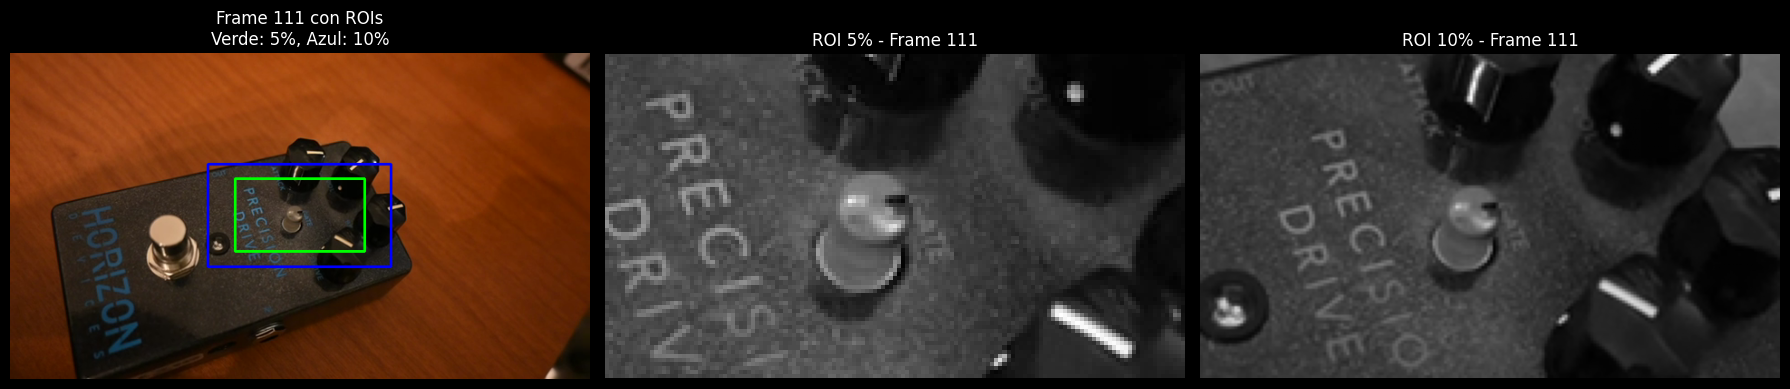

In [36]:
# Visualizar ROIs en el frame de máximo enfoque (ROI 10%)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

frame_show = frames_color[max_frame_10].copy()
h, w = frame_show.shape[:2]

# Dibujar ROI 5%
s5 = np.sqrt(0.05)
x5, y5 = int(w*(1-s5)/2), int(h*(1-s5)/2)
w5, h5 = int(w*s5), int(h*s5)
cv2.rectangle(frame_show, (x5, y5), (x5+w5, y5+h5), (0, 255, 0), 2)

# Dibujar ROI 10%
s10 = np.sqrt(0.10)
x10, y10 = int(w*(1-s10)/2), int(h*(1-s10)/2)
w10, h10 = int(w*s10), int(h*s10)
cv2.rectangle(frame_show, (x10, y10), (x10+w10, y10+h10), (255, 0, 0), 2)

axes[0].imshow(cv2.cvtColor(frame_show, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Frame {max_frame_10} con ROIs\nVerde: 5%, Azul: 10%')
axes[0].axis('off')

roi_5_img = extract_center_roi(frames_gray[max_frame_5], 0.05)
axes[1].imshow(roi_5_img, cmap='gray')
axes[1].set_title(f'ROI 5% - Frame {max_frame_5}')
axes[1].axis('off')

roi_10_img = extract_center_roi(frames_gray[max_frame_10], 0.10)
axes[2].imshow(roi_10_img, cmap='gray')
axes[2].set_title(f'ROI 10% - Frame {max_frame_10}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## Experimento 3 (Opcional): Matriz de enfoque NxM

In [37]:
def compute_focus_matrix(frame_gray, rows, cols):
    """Calcula la métrica FM para cada celda de una grilla rows x cols."""
    h, w = frame_gray.shape
    cell_h = h // rows
    cell_w = w // cols
    
    matrix = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            cell = frame_gray[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            matrix[i, j] = compute_fm(cell)
    return matrix

In [38]:
grid_configs = [(3, 3), (5, 7), (7, 7)]

# Calcular FM promedio de la matriz para cada frame y cada configuración
fm_matrix_results = {}
for (gr, gc) in grid_configs:
    key = f'{gr}x{gc}'
    fm_means = []
    for frame in frames_gray:
        mat = compute_focus_matrix(frame, gr, gc)
        fm_means.append(np.mean(mat))
    fm_matrix_results[key] = fm_means
    max_f, max_v = detect_max_focus(fm_means)
    print(f'Grilla {key} - Frame máx enfoque: {max_f}, FM medio={max_v:.4f}')

Grilla 3x3 - Frame máx enfoque: 111, FM medio=0.1235
Grilla 5x7 - Frame máx enfoque: 111, FM medio=0.1993
Grilla 7x7 - Frame máx enfoque: 111, FM medio=0.2279


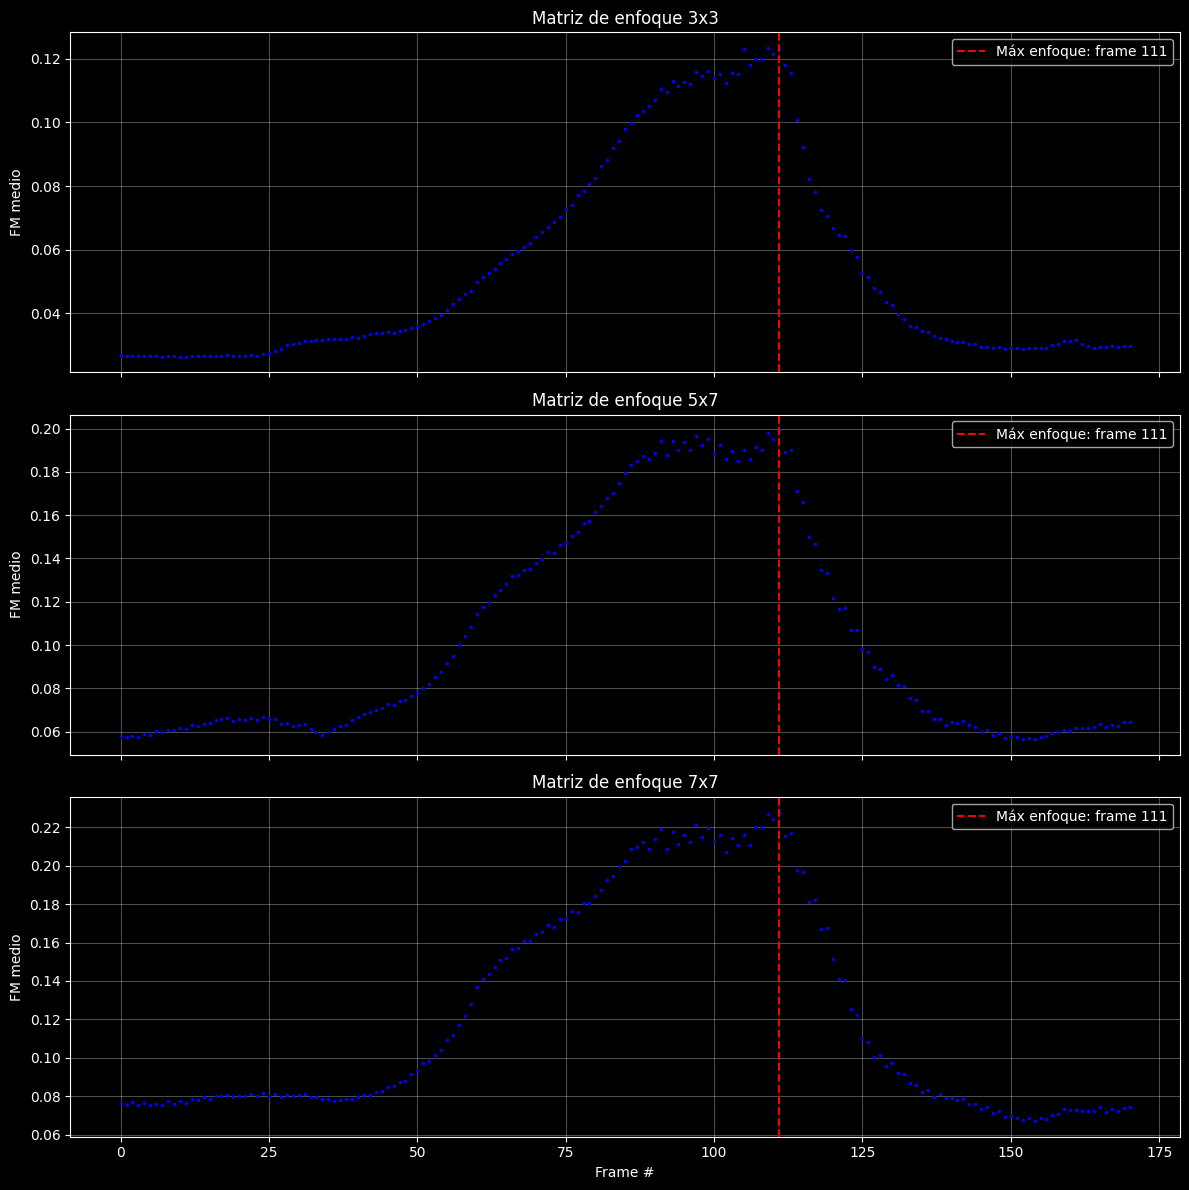

In [39]:
fig, axes = plt.subplots(len(grid_configs), 1, figsize=(12, 4*len(grid_configs)), sharex=True)

for idx, (gr, gc) in enumerate(grid_configs):
    key = f'{gr}x{gc}'
    vals = fm_matrix_results[key]
    max_f, _ = detect_max_focus(vals)
    axes[idx].plot(vals, 'b.', markersize=3)
    axes[idx].axvline(x=max_f, color='r', linestyle='--', label=f'Máx enfoque: frame {max_f}')
    axes[idx].set_ylabel('FM medio')
    axes[idx].set_title(f'Matriz de enfoque {key}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame #')
plt.tight_layout()
plt.show()

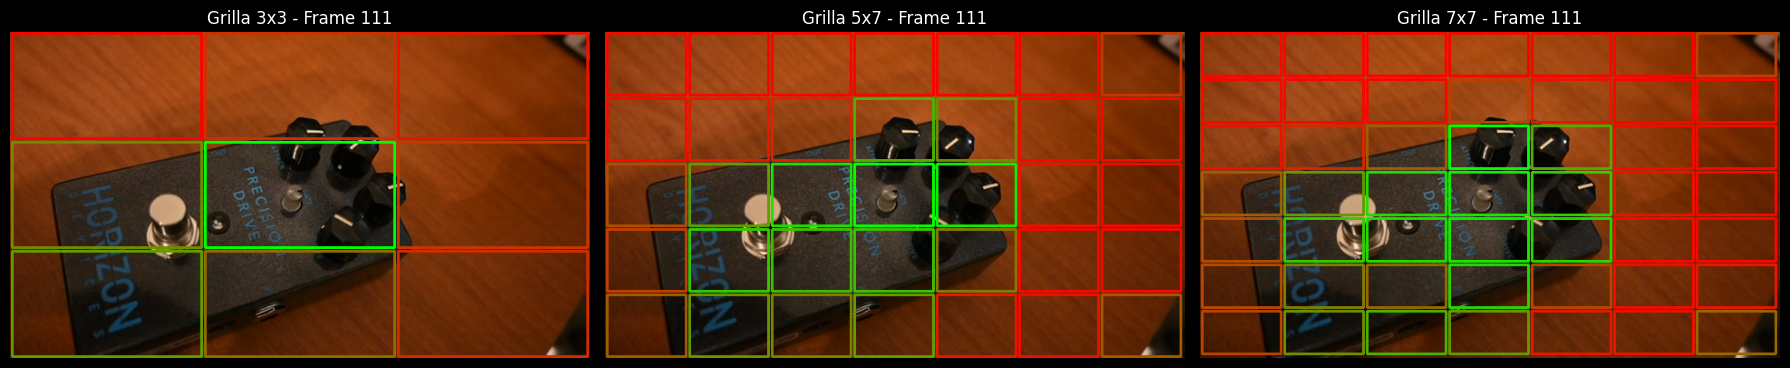

In [40]:
# Visualizar la matriz de enfoque superpuesta al frame de máximo enfoque
fig, axes = plt.subplots(1, len(grid_configs), figsize=(6*len(grid_configs), 5))

for idx, (gr, gc) in enumerate(grid_configs):
    key = f'{gr}x{gc}'
    max_f, _ = detect_max_focus(fm_matrix_results[key])
    
    frame_vis = frames_color[max_f].copy()
    h, w = frame_vis.shape[:2]
    cell_h, cell_w = h // gr, w // gc
    
    focus_mat = compute_focus_matrix(frames_gray[max_f], gr, gc)
    fm_min, fm_max = focus_mat.min(), focus_mat.max()
    
    for i in range(gr):
        for j in range(gc):
            x1, y1 = j * cell_w, i * cell_h
            x2, y2 = x1 + cell_w, y1 + cell_h
            
            # Color según nivel de enfoque (verde=enfocado, rojo=borroso)
            if fm_max > fm_min:
                ratio = (focus_mat[i, j] - fm_min) / (fm_max - fm_min)
            else:
                ratio = 1.0
            color = (0, int(255 * ratio), int(255 * (1 - ratio)))
            cv2.rectangle(frame_vis, (x1+2, y1+2), (x2-2, y2-2), color, 2)
    
    axes[idx].imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Grilla {key} - Frame {max_f}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Punto 2: Métrica alternativa - Laplaciano (Varianza)

Se implementa la métrica basada en la varianza del Laplaciano, una de las métricas
descritas en el apéndice de "Analysis of focus measure operators in shape from focus".

**Laplacian Variance:** Se aplica el operador Laplaciano a la imagen y se calcula
la varianza del resultado. Una imagen enfocada produce bordes más definidos,
resultando en mayor varianza del Laplaciano.

In [41]:
def compute_laplacian_variance(image_gray):
    """Calcula la varianza del Laplaciano como métrica de enfoque."""
    laplacian = cv2.Laplacian(image_gray, cv2.CV_64F)
    return laplacian.var()

In [42]:
# Experimento 1 con Laplaciano: frame completo
lap_full = [compute_laplacian_variance(frame) for frame in frames_gray]
max_frame_lap, max_lap = detect_max_focus(lap_full)
print(f'Laplaciano - Frame máx enfoque: {max_frame_lap}, Varianza={max_lap:.2f}')

Laplaciano - Frame máx enfoque: 111, Varianza=109.23


In [43]:
# Experimento 2 con Laplaciano: ROI central
lap_roi_5 = [compute_laplacian_variance(extract_center_roi(f, 0.05)) for f in frames_gray]
lap_roi_10 = [compute_laplacian_variance(extract_center_roi(f, 0.10)) for f in frames_gray]

max_lap5_f, max_lap5_v = detect_max_focus(lap_roi_5)
max_lap10_f, max_lap10_v = detect_max_focus(lap_roi_10)
print(f'Laplaciano ROI 5%  - Frame máx enfoque: {max_lap5_f}, Var={max_lap5_v:.2f}')
print(f'Laplaciano ROI 10% - Frame máx enfoque: {max_lap10_f}, Var={max_lap10_v:.2f}')

Laplaciano ROI 5%  - Frame máx enfoque: 111, Var=449.29
Laplaciano ROI 10% - Frame máx enfoque: 111, Var=427.53


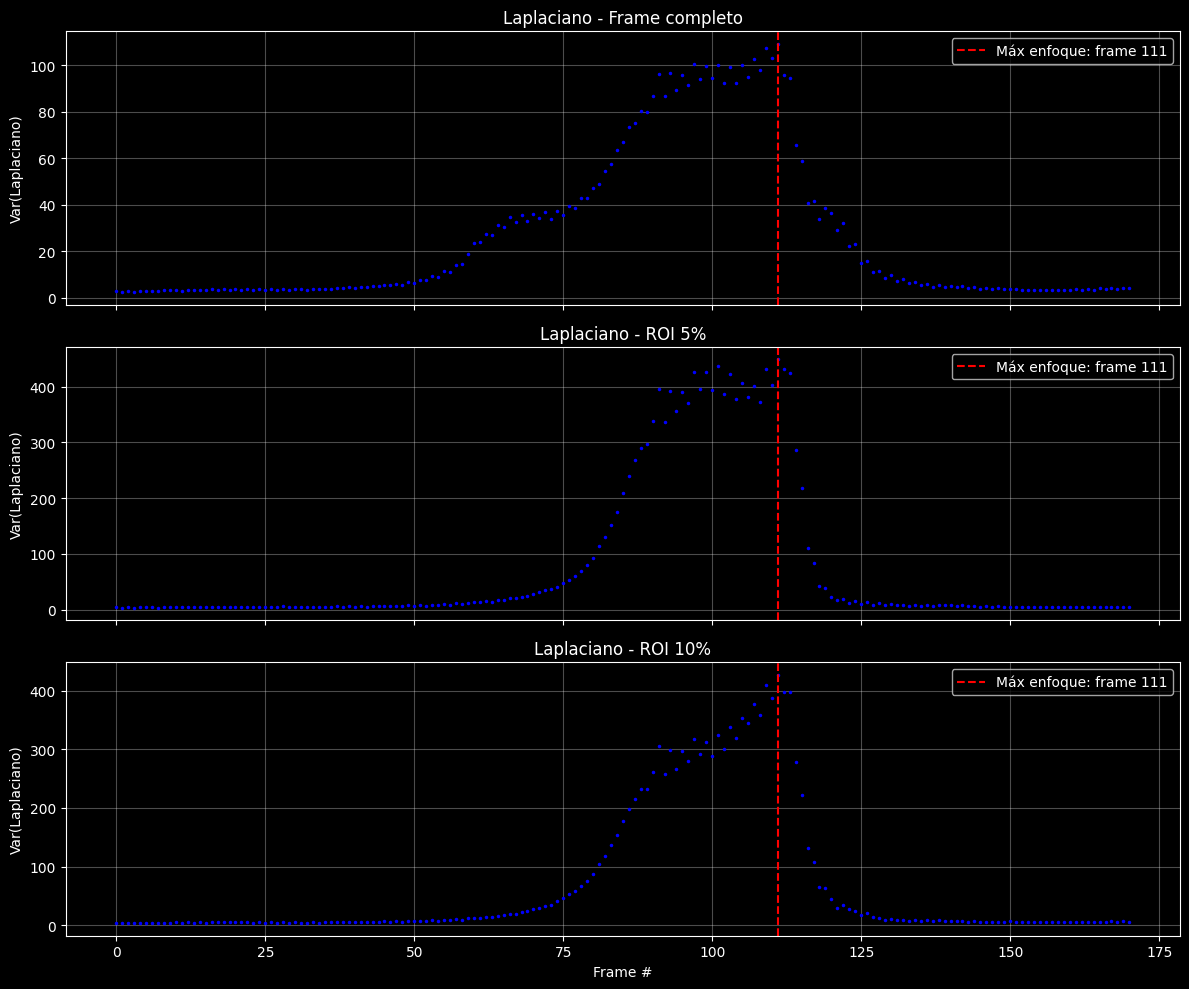

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(lap_full, 'b.', markersize=3)
axes[0].axvline(x=max_frame_lap, color='r', linestyle='--', label=f'Máx enfoque: frame {max_frame_lap}')
axes[0].set_ylabel('Var(Laplaciano)')
axes[0].set_title('Laplaciano - Frame completo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lap_roi_5, 'b.', markersize=3)
axes[1].axvline(x=max_lap5_f, color='r', linestyle='--', label=f'Máx enfoque: frame {max_lap5_f}')
axes[1].set_ylabel('Var(Laplaciano)')
axes[1].set_title('Laplaciano - ROI 5%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(lap_roi_10, 'b.', markersize=3)
axes[2].axvline(x=max_lap10_f, color='r', linestyle='--', label=f'Máx enfoque: frame {max_lap10_f}')
axes[2].set_xlabel('Frame #')
axes[2].set_ylabel('Var(Laplaciano)')
axes[2].set_title('Laplaciano - ROI 10%')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación de métricas

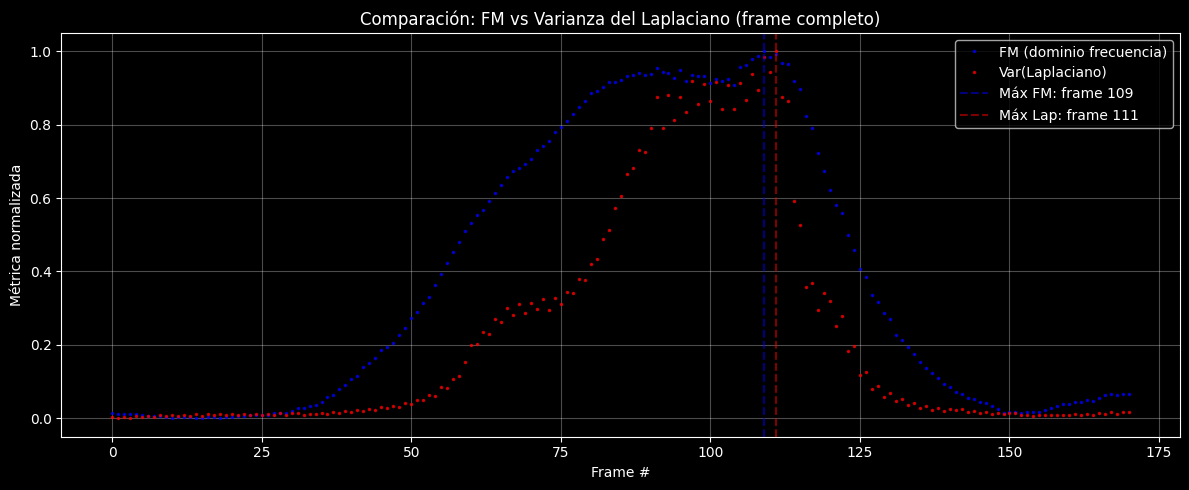

In [45]:
# Normalizar ambas métricas para comparar en el mismo gráfico
def normalize(values):
    v = np.array(values)
    return (v - v.min()) / (v.max() - v.min())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(normalize(fm_full), 'b.', markersize=3, label='FM (dominio frecuencia)', alpha=0.7)
ax.plot(normalize(lap_full), 'r.', markersize=3, label='Var(Laplaciano)', alpha=0.7)

ax.axvline(x=max_frame_full, color='b', linestyle='--', alpha=0.5, label=f'Máx FM: frame {max_frame_full}')
ax.axvline(x=max_frame_lap, color='r', linestyle='--', alpha=0.5, label=f'Máx Lap: frame {max_frame_lap}')

ax.set_xlabel('Frame #')
ax.set_ylabel('Métrica normalizada')
ax.set_title('Comparación: FM vs Varianza del Laplaciano (frame completo)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Puntos extra: Unsharp Masking

In [46]:
def unsharp_mask(image, sigma=1.0, strength=1.5):
    """Aplica unsharp masking para mejorar la nitidez."""
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    return sharpened

In [47]:
# Aplicar unsharp masking a todos los frames y recalcular FM
frames_sharpened = [unsharp_mask(frame) for frame in frames_gray]

fm_sharpened = [compute_fm(frame) for frame in frames_sharpened]
max_frame_sharp, max_fm_sharp = detect_max_focus(fm_sharpened)
print(f'Con Unsharp Masking - Frame máx enfoque: {max_frame_sharp}, FM={max_fm_sharp:.4f}')

Con Unsharp Masking - Frame máx enfoque: 111, FM=0.0481


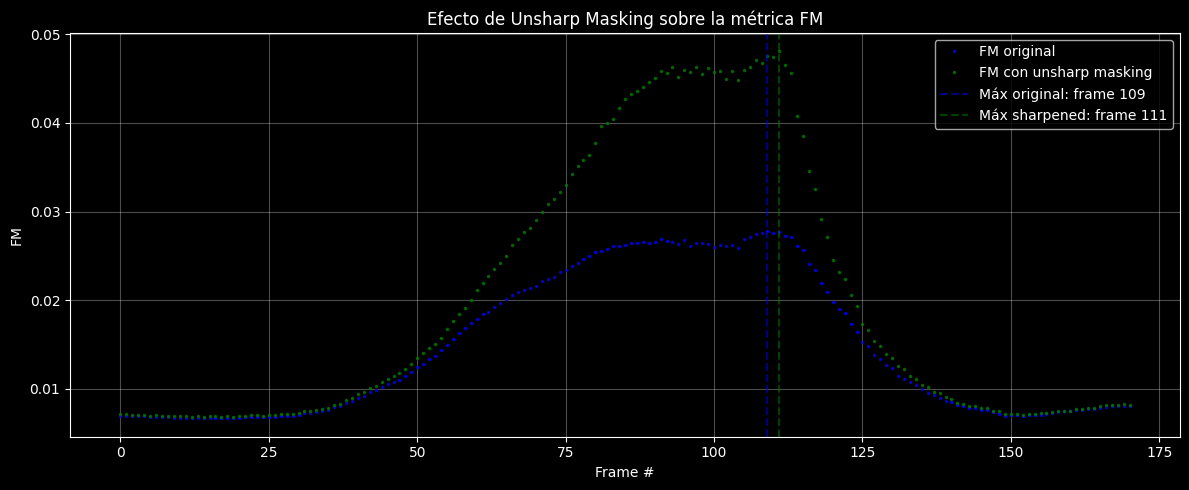

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fm_full, 'b.', markersize=3, label='FM original', alpha=0.7)
ax.plot(fm_sharpened, 'g.', markersize=3, label='FM con unsharp masking', alpha=0.7)

ax.axvline(x=max_frame_full, color='b', linestyle='--', alpha=0.5, label=f'Máx original: frame {max_frame_full}')
ax.axvline(x=max_frame_sharp, color='g', linestyle='--', alpha=0.5, label=f'Máx sharpened: frame {max_frame_sharp}')

ax.set_xlabel('Frame #')
ax.set_ylabel('FM')
ax.set_title('Efecto de Unsharp Masking sobre la métrica FM')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

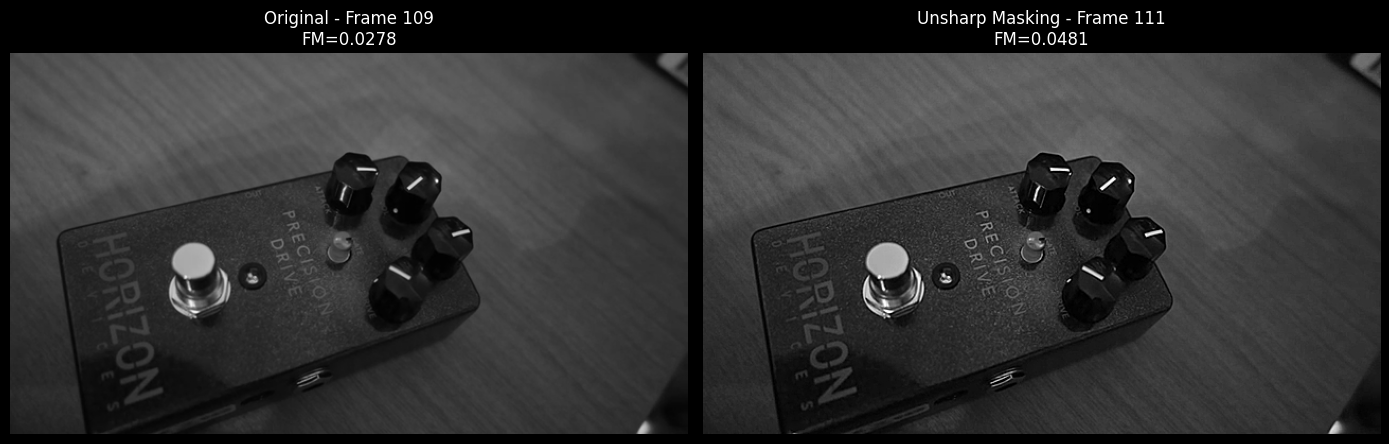

In [49]:
# Comparación visual: frame original vs sharpened
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(frames_gray[max_frame_full], cmap='gray')
axes[0].set_title(f'Original - Frame {max_frame_full}\nFM={fm_full[max_frame_full]:.4f}')
axes[0].axis('off')

axes[1].imshow(frames_sharpened[max_frame_sharp], cmap='gray')
axes[1].set_title(f'Unsharp Masking - Frame {max_frame_sharp}\nFM={fm_sharpened[max_frame_sharp]:.4f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Resumen de resultados

In [50]:
print('=' * 60)
print('RESUMEN - Frames de máximo enfoque detectados')
print('=' * 60)
print(f'\nMétrica FM (dominio frecuencia):')
print(f'  Frame completo:    frame {max_frame_full} (FM={max_fm_full:.4f})')
print(f'  ROI central 5%:    frame {max_frame_5} (FM={max_fm_5:.4f})')
print(f'  ROI central 10%:   frame {max_frame_10} (FM={max_fm_10:.4f})')
for (gr, gc) in grid_configs:
    key = f'{gr}x{gc}'
    mf, mv = detect_max_focus(fm_matrix_results[key])
    print(f'  Grilla {key}:       frame {mf} (FM medio={mv:.4f})')

print(f'\nMétrica Varianza del Laplaciano:')
print(f'  Frame completo:    frame {max_frame_lap} (Var={max_lap:.2f})')
print(f'  ROI central 5%:    frame {max_lap5_f} (Var={max_lap5_v:.2f})')
print(f'  ROI central 10%:   frame {max_lap10_f} (Var={max_lap10_v:.2f})')

print(f'\nCon Unsharp Masking (FM):')
print(f'  Frame completo:    frame {max_frame_sharp} (FM={max_fm_sharp:.4f})')

RESUMEN - Frames de máximo enfoque detectados

Métrica FM (dominio frecuencia):
  Frame completo:    frame 109 (FM=0.0278)
  ROI central 5%:    frame 111 (FM=0.4596)
  ROI central 10%:   frame 111 (FM=0.3531)
  Grilla 3x3:       frame 111 (FM medio=0.1235)
  Grilla 5x7:       frame 111 (FM medio=0.1993)
  Grilla 7x7:       frame 111 (FM medio=0.2279)

Métrica Varianza del Laplaciano:
  Frame completo:    frame 111 (Var=109.23)
  ROI central 5%:    frame 111 (Var=449.29)
  ROI central 10%:   frame 111 (Var=427.53)

Con Unsharp Masking (FM):
  Frame completo:    frame 111 (FM=0.0481)
